File loaded successfully!
Total Columns: 16
Columns in CSV: ['Year', 'Quarter', 'Category', 'Sub-Category', 'Total_Sales', 'Online_Sales', 'Online_Penetration', 'YoY_Growth', 'Region', 'Customer_Segment', 'Marketing_Spend', 'Return_Rate', 'Profit_Margin', 'Growth_Status', 'Marketing_ROI', 'Sales_Per_Million']


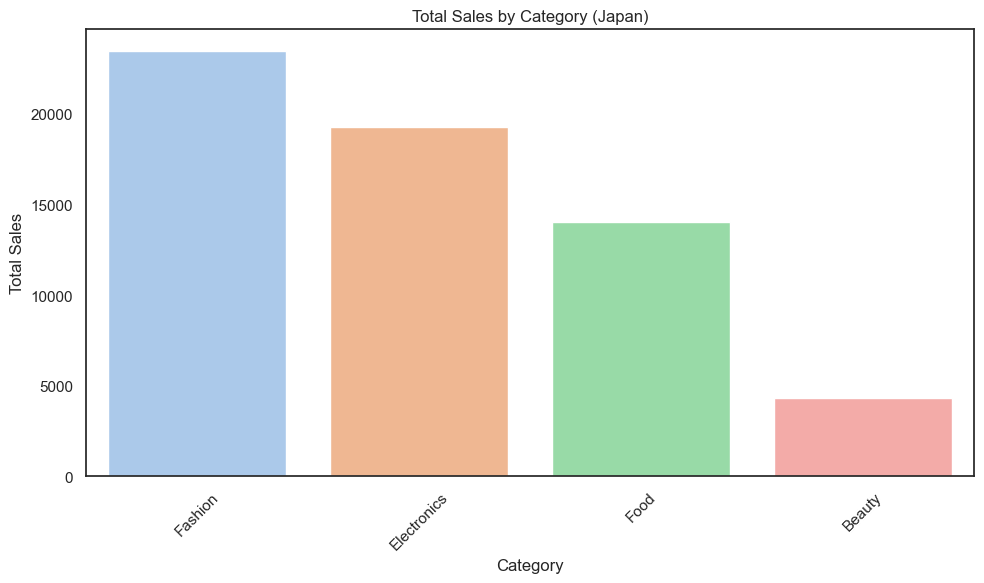

In [54]:
# Project Name: Rising Sun Retail: Japan E-Commerce Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


file_path ="C:/Users/pooja kumari/Downloads/1_Japan_E-commerce_Clean_Data.csv"

try:
    # Load the CSV file
    df = pd.read_csv(file_path, encoding='latin-1')
    print("File loaded successfully!")

    # Clean unwanted columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed|^Column', case=False)]
    df.columns = df.columns.str.strip()  # Remove only extra spaces, keep original case

    print(f"Total Columns: {len(df.columns)}")
    print(f"Columns in CSV: {df.columns.tolist()}")

    # 3. Analysis (Check if 'Category' and 'Total_Sales' columns exist exactly as written in CSV)
    if 'Category' in df.columns and 'Total_Sales' in df.columns:
        
        # Group data by Category and calculate total sales
        category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)

        # Create bar plot
        plt.figure(figsize=(10, 6))
        sns.barplot(x=category_sales.index, y=category_sales.values, palette='pastel')
        plt.title('Total Sales by Category (Japan)')
        plt.xlabel('Category')
        plt.ylabel('Total Sales')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    else:
        print("Error: Columns 'Category' or 'Total_Sales' not found. Please match the exact column names from the list above.")

except Exception as e:
    print(f"An error occurred: {e}")
    print("Tip: Please check your 'Downloads' folder and confirm the file name is exactly 'Japan_E-commerce_Analysis2.csv'.")


In [55]:
# Check specifically for Category column
print("Checking 'Category' column...")

if 'Category' in df.columns:
    print("'Category' column exists")
    print(f"Unique categories: {df['Category'].unique()}")
else:
    print("'Category' column missing")
    print("Available columns:")
    for col in df.columns:
        print(f"- '{col}'")

Checking 'Category' column...
'Category' column exists
Unique categories: ['Electronics' 'Fashion' 'Food' 'Beauty']


In [56]:
#Basic information info
print("All Column names:")
for col in df.columns:
    print(f"-'{col}'")

#Check if 'year' column exists
if 'year' in df.columns:
    print(" 'year' column exists")
else:
    print(" 'year' column does not exist")
if 'year' in df.columns:
    print(" 'year' column exists")
else:
    print(" 'year' column does not exist")
    

All Column names:
-'Year'
-'Quarter'
-'Category'
-'Sub-Category'
-'Total_Sales'
-'Online_Sales'
-'Online_Penetration'
-'YoY_Growth'
-'Region'
-'Customer_Segment'
-'Marketing_Spend'
-'Return_Rate'
-'Profit_Margin'
-'Growth_Status'
-'Marketing_ROI'
-'Sales_Per_Million'
 'year' column does not exist
 'year' column does not exist


In [57]:
# Basic dataset info - CORRECTED
print("JAPAN E-COMMERCE ANALYSIS")
print("=" * 30)
print(f"Total Records: {len(df)}")
print(f"Time Period: {df['Year'].min()} to {df['Year'].max()}")
print(f"Categories: {df['Category'].nunique()} categories")
print("\nFirst 3 rows:")
print(df.head(3))

JAPAN E-COMMERCE ANALYSIS
Total Records: 39
Time Period: 2018 to 2023
Categories: 4 categories

First 3 rows:
   Year Quarter     Category Sub-Category  Total_Sales  Online_Sales  \
0  2023      Q4  Electronics  Smartphones         1250           650   
1  2023      Q4  Electronics      Laptops          980           539   
2  2023      Q4  Electronics          TVs          820           410   

   Online_Penetration  YoY_Growth  Region Customer_Segment  Marketing_Spend  \
0                  52         8.5   Kanto            Youth              120   
1                  55         7.2  Kansai    Professionals               95   
2                  50         5.5  Kyushu         Families               80   

   Return_Rate  Profit_Margin Growth_Status  Marketing_ROI  Sales_Per_Million  
0          2.1        516.350        Medium       5.416667              0.650  
1          1.8        434.298        Medium       5.673684              0.539  
2          2.5        319.750        Medium 

CATEGORY SALES ANALYSIS
Beauty: 1,747 Billion ¥
Electronics: 9,248 Billion ¥
Fashion: 8,209 Billion ¥
Food: 1,179 Billion ¥


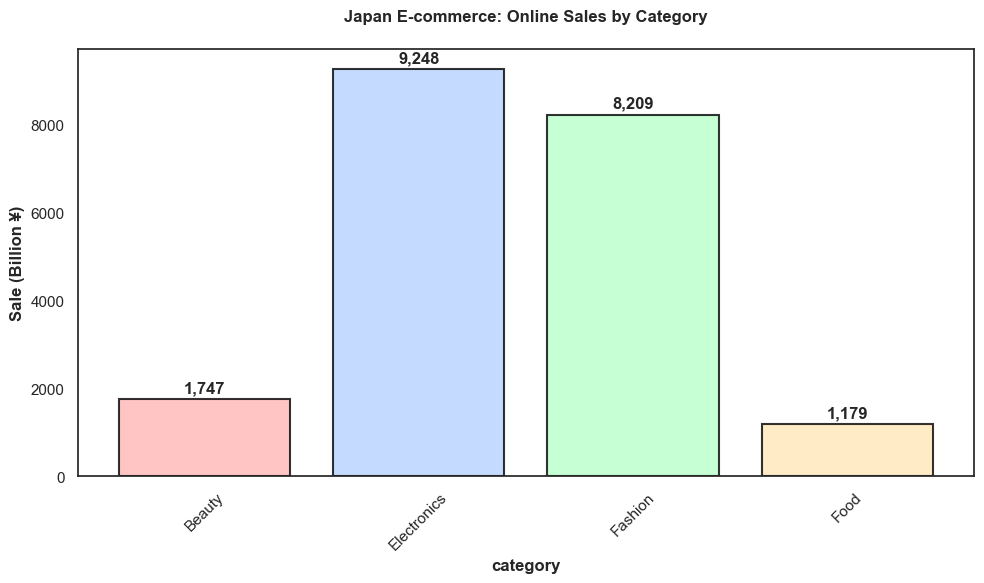

In [58]:
#Better Formatted Sales analysis
print("CATEGORY SALES ANALYSIS")
print("=" * 30)
category_sales =df.groupby('Category')['Online_Sales'].sum()
for category, sale in category_sales.items():
    

    #format numbers properly
    formatted_sale=f"{sale:,.0f}"          #ass commas to large number
    print(f"{category}: {formatted_sale} Billion ¥")


#Better bar chart
plt.figure(figsize=(10, 6))
colors=['#FFB7B7','#B7D1FF','#B7FFC8','#FFE6B7'] # FIXED: Changed 'color' to 'colors'
bars=plt.bar(category_sales.index, category_sales.values, color=colors,edgecolor='black', linewidth=1.5, alpha=0.8) # FIXED: Changed 'color' to 'colors'
            
plt.title('Japan E-commerce: Online Sales by Category',fontweight='bold', pad=20)
plt.xlabel('category', fontweight='bold')
plt.ylabel('Sale (Billion ¥)',fontweight='bold')
plt.xticks(rotation=45)

#Add values on bars
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{height:,.0f}', ha='center',va='bottom',fontweight='bold')
plt.tight_layout()
plt.show()

ONLINE PENETRATION ANALYSIS
Electronics: 48.2%
Beauty: 40.7%
Fashion: 34.8%
Food: 8.2%


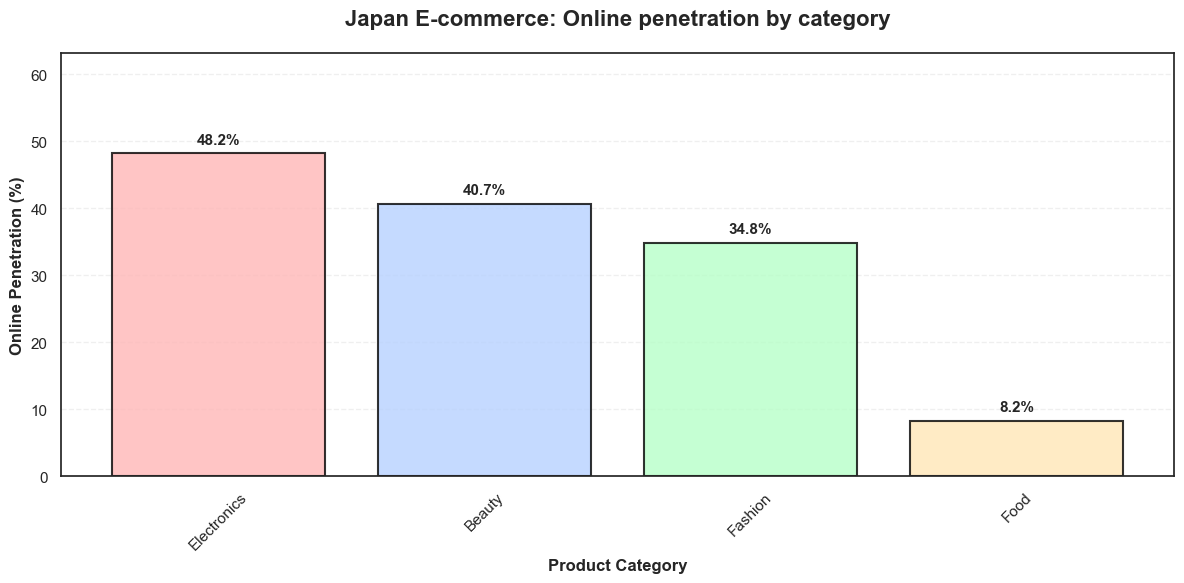

In [59]:
#online penetration analysis
print("ONLINE PENETRATION ANALYSIS")
print("=" *40)
penetration = df.groupby('Category')['Online_Penetration'].mean().sort_values(ascending=False)

for category, percent in penetration.items(): # FIXED: Changed 'catrgory' to 'category'
    print(f"{category}: {percent:.1f}%")
#Bar chart with light colors
plt.figure(figsize=(12,6))
colors=['#FFB7B7','#B7D1FF','#B7FFC8','#FFE6B7']

bars = plt.bar(penetration.index,penetration.values, 
               color=colors, edgecolor='black', linewidth=1.5,alpha=0.8) # FIXED: Changed 'color' to 'color'


plt.title('Japan E-commerce: Online penetration by category', fontsize=16,fontweight='bold',pad=20)
plt.xlabel('Product Category', fontsize=12, fontweight='bold')
plt.ylabel('Online Penetration (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

#Add values on bar
for i, value in enumerate(penetration.values):
    plt.text(i,value+ 1,f'{value:.1f}%', ha='center',va='bottom',fontweight='bold',fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, penetration.max() + 15)     #Extra space for labes
plt.tight_layout()
plt.show()

CALCULATING GROWTH RATES....
Yearly Online Sales:
Year
2018      304
2019      818
2020      880
2021     1331
2022     5902
2023    11148
Name: Online_Sales, dtype: int64

Year-over-Year Growth (%):
Year
2018           NaN
2019    169.078947
2020      7.579462
2021     51.250000
2022    343.425995
2023     88.885124
Name: Online_Sales, dtype: float64


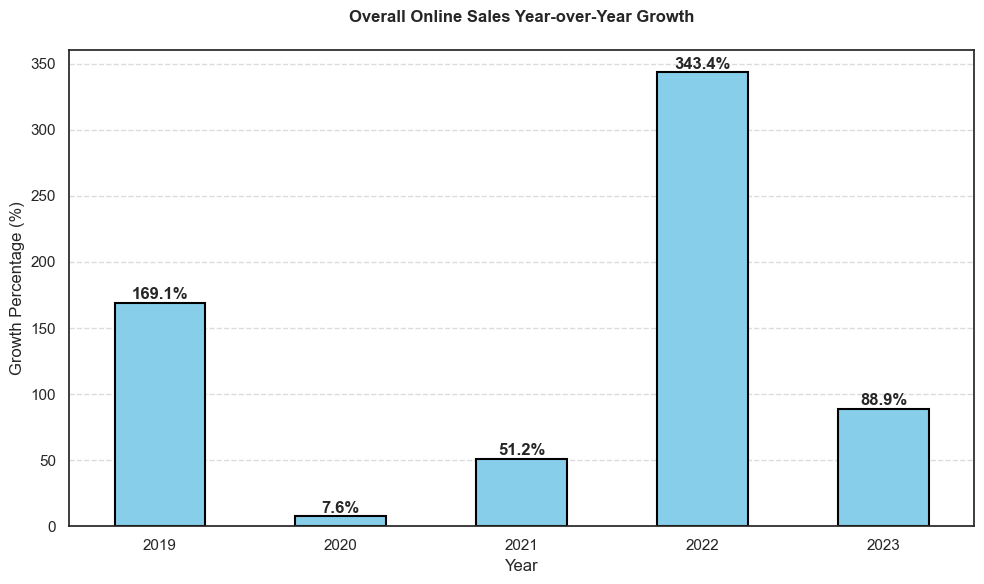

In [60]:
#Growth analysis - ACTUALLY CALCULATING GROWTH NOW
print("CALCULATING GROWTH RATES....")

# Calculate total online sales per year
yearly_sales = df.groupby('Year')['Online_Sales'].sum()

# Calculate Year-over-Year (YoY) growth percentage
yoy_growth = yearly_sales.pct_change() * 100

print("Yearly Online Sales:")
print(yearly_sales)
print("\nYear-over-Year Growth (%):")
print(yoy_growth)

# Plot the growth
plt.figure(figsize=(10, 6))
yoy_growth.dropna().plot(kind='bar', color='skyblue',edgecolor='black',linewidth=1.5) # dropna() removes the first year which has no growth

plt.title('Overall Online Sales Year-over-Year Growth', fontweight='bold', pad=20)
plt.xlabel('Year')
plt.ylabel('Growth Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, value in enumerate(yoy_growth.dropna()):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

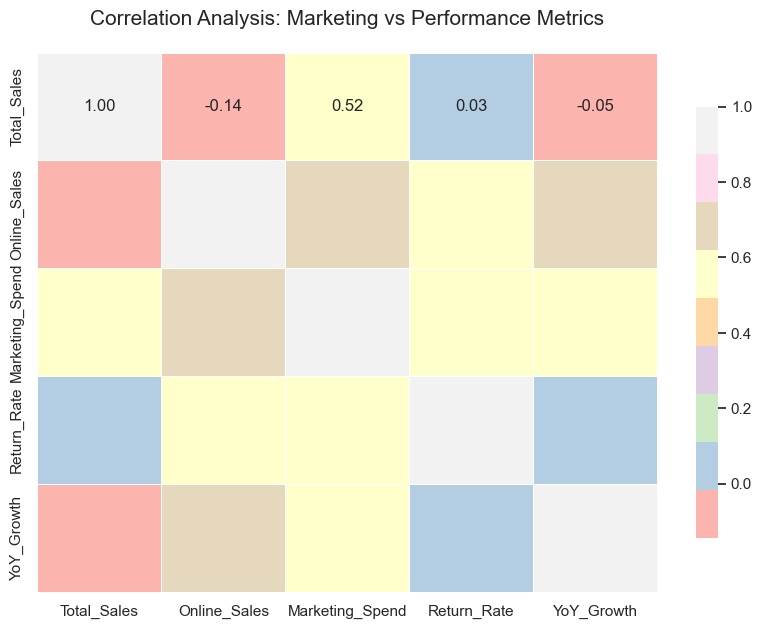

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Correlation Matrix
# We will check correlation only for numerical columns
corr_matrix = df[['Total_Sales', 'Online_Sales', 'Marketing_Spend', 'Return_Rate', 'YoY_Growth']].corr()

# 2. Create Heatmap
plt.figure(figsize=(10, 7))
sns.set_theme(style="white")  # Keep background clean and minimal

# Using a soft professional color palette (YlGnBu) for better readability
sns.heatmap(corr_matrix, 
            annot=True,               # Display correlation values inside cells
            fmt=".2f",                # Limit decimal points to 2 places
            cmap="Pastel1",            # Soft and professional color scheme
            linewidths=0.5,           # Add spacing between cells
            cbar_kws={"shrink": .8})  # Adjust color bar size

plt.title('Correlation Analysis: Marketing vs Performance Metrics', fontsize=15, pad=20)
plt.show()


In [62]:
# first check all columns
print("All columns in your data:")
for col in df.columns:
    print(f"- '{col}'")

# Specifically check for YoY_Growth
print(f"\nYoY_Growth column exists: {'YoY_Growth' in df.columns}")

All columns in your data:
- 'Year'
- 'Quarter'
- 'Category'
- 'Sub-Category'
- 'Total_Sales'
- 'Online_Sales'
- 'Online_Penetration'
- 'YoY_Growth'
- 'Region'
- 'Customer_Segment'
- 'Marketing_Spend'
- 'Return_Rate'
- 'Profit_Margin'
- 'Growth_Status'
- 'Marketing_ROI'
- 'Sales_Per_Million'

YoY_Growth column exists: True


In [68]:
import pandas as pd

# Data load karo

df = pd.read_csv('C:/Users/pooja kumari/Downloads/1_Japan_E-commerce_Clean_Data.csv', encoding='latin-1')

print("Data loaded successfully!")
print(f"Data shape: {df.shape}")

Data loaded successfully!
Data shape: (39, 16)


In [69]:
# Check actual values in YoY_Growth column
if 'YoY_Growth' in df.columns:
    print("YoY_Growth values preview:")
    print(df['YoY_Growth'].head(10))
    print(f"\nAverage YoY Growth: {df['YoY_Growth'].mean():.1f}%")
else:
    print("YoY_Growth column nahi hai data mein!")
    print("Available numeric columns:")
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        print(f"- {col}")

YoY_Growth values preview:
0     8.5
1     7.2
2     5.5
3    12.3
4     9.8
5     8.4
6     4.2
7     3.1
8    15.7
9    14.2
Name: YoY_Growth, dtype: float64

Average YoY Growth: 6.6%


In [70]:
# Performance Summary - AFTER RELOADING DATA
print("JAPAN E-COMMERCE - PERFORMANCE SUMMARY")
print("=" * 50)

# Check if columns exist before using
if 'Category' in df.columns and 'Online_Sales' in df.columns:
    category_sales = df.groupby('Category')['Online_Sales'].sum()
    penetration = df.groupby('Category')['Online_Penetration'].mean()
    growth = df.groupby('Category')['YoY_Growth'].mean()
    
    print("All metrics calculated successfully!")
    print(f"Analysis Period: {df['Year'].min()}-{df['Year'].max()}")
    print(f"Total Records: {len(df)}")
    print(f"Categories: {df['Category'].nunique()}")
    
    print("\nTOP PERFORMERS:")
    print(f"• Highest Sales: {category_sales.idxmax()} ({category_sales.max():,.0f}B ¥)")
    print(f"• Highest Online Penetration: {penetration.idxmax()} ({penetration.max():.1f}%)")
    print(f"• Highest Growth: {growth.idxmax()} ({growth.max():.1f}%)")
    
    print("\nGROWTH RATES BY CATEGORY:")
    for category, growth_rate in growth.items():
        print(f"  {category}: {growth_rate:.1f}%")
else:
    print("Required columns missing!")
    print("Available columns:", list(df.columns))

JAPAN E-COMMERCE - PERFORMANCE SUMMARY
All metrics calculated successfully!
Analysis Period: 2018-2023
Total Records: 39
Categories: 4

TOP PERFORMERS:
• Highest Sales: Electronics (9,248B ¥)
• Highest Online Penetration: Electronics (48.2%)
• Highest Growth: Beauty (14.2%)

GROWTH RATES BY CATEGORY:
  Beauty: 14.2%
  Electronics: 5.4%
  Fashion: 7.5%
  Food: 3.4%


In [71]:
#Business Recommendation
print("BUINESS RECOMMENDATIONS")
print("=" * 35)

print("ELECTONICS (Market leader):")
print(".Maintain quality leadership")
print(".Fous on customer retention")
print(".introduce premium products")

print("BEAUTY(High Growth):")
print(".Capitalize on 14.2% growth")
print(".Social media marketing")

print("FASHION(Steady Performer):")
print(".Improve online shoping experience")
print(".Virtual try-on features")
print(".Size customization")

print("FOOD(Oppratunity Area):")
print(".Invest in online platforms")
print(".Same-day delivery service")
print(".Subscription models")

BUINESS RECOMMENDATIONS
ELECTONICS (Market leader):
.Maintain quality leadership
.Fous on customer retention
.introduce premium products
BEAUTY(High Growth):
.Capitalize on 14.2% growth
.Social media marketing
FASHION(Steady Performer):
.Improve online shoping experience
.Virtual try-on features
.Size customization
FOOD(Oppratunity Area):
.Invest in online platforms
.Same-day delivery service
.Subscription models


In [73]:
full_path = r"C:\Users\pooja kumari\OneDrive\Desktop\Japan_Ecommerce_Cleaned.csv"
final_powerbi_df = df.loc[:, ~df.columns.str.contains('^Unnamed|^Column', case=False)].copy()
final_powerbi_df.to_csv(full_path, index=False)

print(f"Total Columns Saved: {len(final_powerbi_df.columns)}")
print(f"Columns Saved: {final_powerbi_df.columns.tolist()}")
print(f"Total Rows Saved: {len(final_powerbi_df)}")

Total Columns Saved: 16
Columns Saved: ['Year', 'Quarter', 'Category', 'Sub-Category', 'Total_Sales', 'Online_Sales', 'Online_Penetration', 'YoY_Growth', 'Region', 'Customer_Segment', 'Marketing_Spend', 'Return_Rate', 'Profit_Margin', 'Growth_Status', 'Marketing_ROI', 'Sales_Per_Million']
Total Rows Saved: 39
